###Nama  : Yildi Andriana
###NIM   : 1237050009

#Import Library

Pada tahap pertama, kita memanggil library yang dibutuhkan untuk proses analisis dan clustering menggunakan metode K-Means.

Penjelasan library:

pandas digunakan untuk membaca dan mengolah dataset.
numpy digunakan untuk operasi numerik dan array.
matplotlib.pyplot digunakan untuk membuat visualisasi data.
seaborn digunakan untuk membantu visualisasi data.
KMeans digunakan untuk membuat model clustering K-Means.
MinMaxScaler digunakan untuk normalisasi data agar semua fitur memiliki skala yang seimbang.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

#Load Dataset Produksi Sayuran

Dataset yang digunakan pada percobaan ini adalah dataset Produksi Sayuran yang berisi data produksi berbagai jenis sayuran di beberapa provinsi.

Dataset dibaca menggunakan pandas agar dapat diolah dalam bentuk dataframe.

In [11]:
baca = pd.read_csv("Produksi Sayur.csv")

baca.head()

,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,NaN,Produksi Tanaman Sayuran,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Bawang Merah (Ton),Bawang Putih (Ton),Bawang Daun (Ton),Kentang (Ton),Kubis (Ton),Kembang Kol (Ton),Petsai/Sawi (Ton),Wortel (Ton),Lobak (Ton),...,Buncis (Ton),Ketimun (Ton),Labu Siam (Ton),Kangkung (Ton),Bayam (Ton),Melinjo (Ton),Paprika (Ton),Jamur (Kg),Petai (Ton),Jengkol (Ton)
2,NaN,2023,2023,2023,2023,2023,2023,2023,2023,2023,...,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023
3,ACEH,13673,20,1193,9109,8592,417,3055,191,-,...,625,14864,2591,7125,4275,31782,1,10,2273,7982
4,SUMATERA UTARA,65585,15,17669,139172,228099,57384,77970,145810,-,...,48328,28573,16330,25017,16895,3701,4,62,25960,9963


#Melihat Informasi Dataset

Perintah info() digunakan untuk melihat:

jumlah data,
jumlah kolom,
tipe data,
serta memastikan dataset berhasil dibaca.

Tahap ini penting untuk mengetahui apakah terdapat data non numerik yang perlu diproses terlebih dahulu

In [12]:
baca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   38 Provinsi  39 non-null     object
 1   Unnamed: 1   42 non-null     object
 2   Unnamed: 2   41 non-null     object
 3   Unnamed: 3   41 non-null     object
 4   Unnamed: 4   41 non-null     object
 5   Unnamed: 5   41 non-null     object
 6   Unnamed: 6   41 non-null     object
 7   Unnamed: 7   41 non-null     object
 8   Unnamed: 8   41 non-null     object
 9   Unnamed: 9   41 non-null     object
 10  Unnamed: 10  41 non-null     object
 11  Unnamed: 11  41 non-null     object
 12  Unnamed: 12  41 non-null     object
 13  Unnamed: 13  41 non-null     object
 14  Unnamed: 14  41 non-null     object
 15  Unnamed: 15  41 non-null     object
 16  Unnamed: 16  41 non-null     object
 17  Unnamed: 17  41 non-null     object
 18  Unnamed: 18  41 non-null     object
 19  Unnamed: 19  41 non-null     ob

#Melihat Nama Kolom Dataset

Tahap ini dilakukan untuk mengetahui nama kolom yang ada pada dataset.

Hal ini penting karena pada dataset produksi sayuran, nama kolom pertama digunakan sebagai identitas provinsi sehingga tidak digunakan dalam proses clustering.

In [13]:
print(baca.columns.tolist())

['38 Provinsi', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


#Menghapus Kolom Provinsi

Kolom identitas provinsi tidak digunakan dalam proses K-Means karena K-Means hanya dapat memproses data numerik.

Oleh karena itu, kolom '38 Provinsi' dihapus dari dataset.


In [14]:
baca = baca.drop(['38 Provinsi'], axis=1)

baca.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Produksi Tanaman Sayuran,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bawang Merah (Ton),Bawang Putih (Ton),Bawang Daun (Ton),Kentang (Ton),Kubis (Ton),Kembang Kol (Ton),Petsai/Sawi (Ton),Wortel (Ton),Lobak (Ton),Kacang Merah (Ton),...,Buncis (Ton),Ketimun (Ton),Labu Siam (Ton),Kangkung (Ton),Bayam (Ton),Melinjo (Ton),Paprika (Ton),Jamur (Kg),Petai (Ton),Jengkol (Ton)
2,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023,...,2023,2023,2023,2023,2023,2023,2023,2023,2023,2023
3,13673,20,1193,9109,8592,417,3055,191,-,-,...,625,14864,2591,7125,4275,31782,1,10,2273,7982
4,65585,15,17669,139172,228099,57384,77970,145810,-,-,...,48328,28573,16330,25017,16895,3701,4,62,25960,9963


#Membersihkan dan Mengubah Data Menjadi Numerik

Pada dataset terdapat beberapa data yang memiliki simbol '-' atau nilai kosong.

Tahap ini dilakukan untuk:

Mengganti simbol '-' menjadi 0
Mengubah seluruh data menjadi numerik
Mengisi nilai kosong (NaN) dengan 0

Tahap preprocessing ini penting agar data dapat diproses oleh algoritma K-Means.

In [15]:
# Mengganti tanda '-' menjadi 0
baca = baca.replace('-', 0)

# Mengubah semua data menjadi numerik
baca = baca.apply(pd.to_numeric, errors='coerce')

# Mengisi nilai kosong
baca = baca.fillna(0)

baca.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,...,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0,2023.0
3,13673.0,20.0,1193.0,9109.0,8592.0,417.0,3055.0,191.0,0.0,0.0,...,625.0,14864.0,2591.0,7125.0,4275.0,31782.0,1.0,10.0,2273.0,7982.0
4,65585.0,15.0,17669.0,139172.0,228099.0,57384.0,77970.0,145810.0,0.0,0.0,...,48328.0,28573.0,16330.0,25017.0,16895.0,3701.0,4.0,62.0,25960.0,9963.0


#Menentukan Variabel untuk Clustering

Pada tahap ini dipilih beberapa variabel produksi sayuran yang akan digunakan dalam proses clustering.

Variabel ini nantinya digunakan untuk menentukan kemiripan antar data.

In [16]:
# Menentukan variabel clustering
baca_x = baca.iloc[:, 0:3]

baca_x.head()

,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,2023.0,2023.0,2023.0
3,13673.0,20.0,1193.0
4,65585.0,15.0,17669.0


#Visualisasi Persebaran Data

Sebelum melakukan clustering, data divisualisasikan terlebih dahulu untuk melihat persebaran awal data.

Grafik scatter digunakan untuk melihat hubungan antar variabel produksi sayuran.

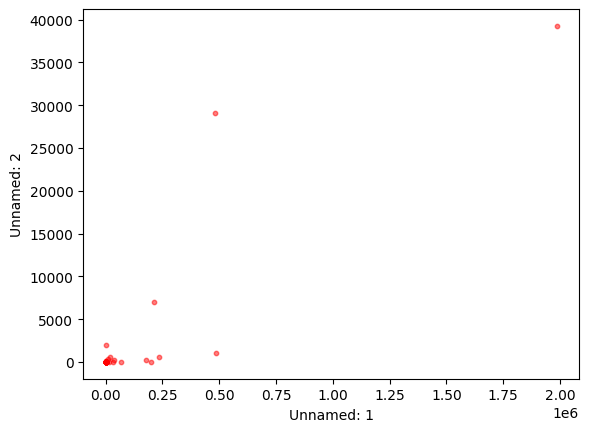

In [17]:
plt.scatter(
    baca_x.iloc[:,0],
    baca_x.iloc[:,1],
    s=10,
    c="red",
    marker="o",
    alpha=0.5
)

plt.xlabel(baca_x.columns[0])
plt.ylabel(baca_x.columns[1])

plt.show()

#Mengubah Dataframe Menjadi Array

Algoritma K-Means bekerja lebih optimal dengan data berbentuk array.

Oleh karena itu, dataframe diubah menjadi array menggunakan numpy

In [18]:
x_array = np.array(baca_x)

print(x_array)

[[0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00]
 [2.023000e+03 2.023000e+03 2.023000e+03]
 [1.367300e+04 2.000000e+01 1.193000e+03]
 [6.558500e+04 1.500000e+01 1.766900e+04]
 [2.339170e+05 5.880000e+02 6.207300e+04]
 [3.230000e+02 0.000000e+00 1.700000e+01]
 [1.840100e+04 5.270000e+02 9.422000e+03]
 [1.197000e+03 5.000000e+01 3.022000e+03]
 [6.710000e+02 1.500000e+01 1.636000e+04]
 [2.193000e+03 1.000000e+00 3.742000e+03]
 [1.760000e+02 0.000000e+00 5.000000e+02]
 [1.700000e+01 0.000000e+00 2.110000e+02]
 [0.000000e+00 0.000000e+00 0.000000e+00]
 [1.793550e+05 2.080000e+02 1.631360e+05]
 [4.790910e+05 2.904700e+04 1.259420e+05]
 [3.295300e+04 0.000000e+00 2.440000e+02]
 [4.846690e+05 1.053000e+03 1.214210e+05]
 [8.600000e+02 0.000000e+00 2.700000e+02]
 [3.537400e+04 1.670000e+02 8.180000e+02]
 [2.126180e+05 7.057000e+03 2.330000e+03]
 [1.140900e+04 3.460000e+02 1.635000e+03]
 [1.090000e+02 0.000000e+00 8.330000e+02]
 [7.200000e+01 0.000000e+00 1.3810

#Normalisasi Data Menggunakan MinMaxScaler

K-Means bekerja berdasarkan perhitungan jarak antar data.

Karena setiap jenis sayuran memiliki skala produksi yang berbeda, maka diperlukan normalisasi agar tidak ada fitur yang mendominasi proses clustering.

Metode yang digunakan adalah MinMaxScaler

In [19]:
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x_array)

print(x_scaled)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.01902396e-03 5.15361492e-02 3.16254348e-03]
 [6.88735277e-03 5.09502216e-04 1.86500958e-03]
 [3.30364244e-02 3.82126662e-04 2.76218392e-02]
 [1.17828487e-01 1.49793652e-02 9.70383398e-02]
 [1.62701305e-04 0.00000000e+00 2.65759956e-05]
 [9.26893720e-03 1.34253834e-02 1.47293548e-02]
 [6.02951895e-04 1.27375554e-03 4.72427405e-03]
 [3.37995590e-04 3.82126662e-04 2.55754876e-02]
 [1.10465623e-03 2.54751108e-05 5.84984562e-03]
 [8.86545811e-05 0.00000000e+00 7.81646930e-04]
 [8.56322658e-06 0.00000000e+00 3.29855004e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.03445591e-02 5.29882305e-03 2.55029507e-01]
 [2.41327340e-01 7.39975544e-01 1.96884355e-01]
 [1.65990592e-02 0.00000000e+00 3.81443702e-04]
 [2.44137086e-01 2.68252917e-02 1.89816704e-01]
 [4.33198521e-04 0.00000000e+00 4.22089342e-04]
 [1.78185634e-02 4.25434351e-03 1.27877438e-03]
 [1.07099771e-01 1.79777857e-01 3.642474

#Membuat Model K-Means

Pada percobaan ini digunakan jumlah cluster sebanyak 3.

Tujuan penggunaan 3 cluster adalah untuk mengelompokkan provinsi berdasarkan tingkat kemiripan produksi sayuran.

In [20]:
# Membuat model KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Training model
kmeans.fit(x_scaled)

KMeans(n_clusters=3, random_state=42)

#Menampilkan Label Cluster

Setelah proses training selesai, setiap data akan mendapatkan label cluster.

Label cluster berupa angka seperti:

0
1
2

Angka tersebut menunjukkan kelompok hasil clustering.

In [21]:
print(kmeans.labels_)

[1 1 1 1 1 2 1 1 1 1 1 1 1 1 2 0 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0]


#Menambahkan Hasil Cluster ke Dataset

Hasil clustering kemudian ditambahkan ke dataframe sebagai kolom baru bernama kluster.

Dengan demikian, setiap data provinsi memiliki informasi cluster masing-masing.

In [22]:
baca["kluster"] = kmeans.labels_

print(baca.head())

   Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2      2023.0      2023.0      2023.0      2023.0      2023.0      2023.0   
3     13673.0        20.0      1193.0      9109.0      8592.0       417.0   
4     65585.0        15.0     17669.0    139172.0    228099.0     57384.0   

   Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  ...  Unnamed: 17  \
0         0.0         0.0         0.0          0.0  ...          0.0   
1         0.0         0.0         0.0          0.0  ...          0.0   
2      2023.0      2023.0      2023.0       2023.0  ...       2023.0   
3      3055.0       191.0         0.0          0.0  ...      14864.0   
4     77970.0    145810.0         0.0          0.0  ...      28573.0   

   Unnamed: 18  Unnamed: 19  Unnamed: 20  Unnamed: 21  Unnamed: 22  \
0          0.0          0.0       

#Melihat Jumlah Data pada Setiap Cluster

Tahap ini dilakukan untuk mengetahui jumlah data yang masuk ke masing-masing cluster.

In [23]:
print(baca["kluster"].value_counts())

kluster
1    37
2     3
0     2
Name: count, dtype: int64


#Visualisasi Hasil Clustering

Visualisasi dilakukan untuk melihat hasil pengelompokan data berdasarkan cluster yang terbentuk.

Setiap warna menunjukkan cluster yang berbeda.

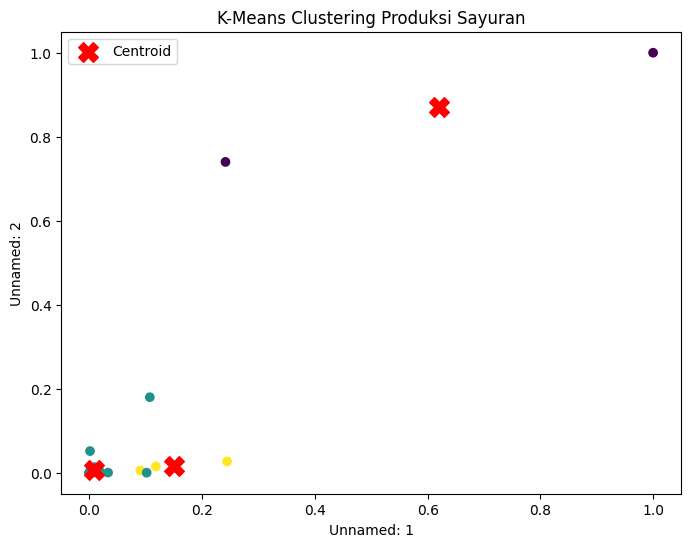

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c=baca['kluster'],
    cmap='viridis'
)

# Titik centroid
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel(baca_x.columns[0])
plt.ylabel(baca_x.columns[1])

plt.title('K-Means Clustering Produksi Sayuran')

plt.legend()

plt.show()

#Kesimpulan

Pada percobaan ini, algoritma K-Means Clustering berhasil diterapkan pada dataset Produksi Sayuran.

Tahapan yang dilakukan meliputi:

membaca dataset,
membersihkan data,
normalisasi,
proses clustering,
hingga visualisasi hasil cluster.

Hasil clustering menunjukkan bahwa provinsi dapat dikelompokkan berdasarkan kemiripan produksi sayuran.

Metode K-Means sangat cocok digunakan untuk analisis pola produksi karena mampu mengelompokkan data berdasarkan karakteristik yang mirip tanpa menggunakan label data sebelumnya.